In [4]:
#1) IMPORT NECESSARY LIBRARIES

import pandas as pd
import pmdarima as pm
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [5]:
#2) LOAD THE DATA
data=pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Time series analysis/merged files/csv/adbe_data.csv')

In [6]:
#3) DO SOME CLEANING IF NECESSARY

data = data.drop(columns=['Unnamed: 0'])

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d", errors="coerce")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

In [7]:
#4) CREATE BACKTESTING DATASET

data_bt = data.iloc[:-4]

START THE SET UP FOR THE PROPHET MODEL

In [8]:
#5) ADD A FUTURE BASE SCENARIO SO PROPHET CAN FORECAST

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº of quarters to forecast
FREQ = "Q"            # trimestral frecuency
REG_COLS = ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd",  "share_holder_equity_musd", "gdp_growth", "interest_rate"]
# ================== PREP ====================
df = data.copy()

# Make sure that the regressors exist (if any are missing, we create them as Nan)  
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convert gdp_growth to numeric if it's not already
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Fill empty slots with forward-fill (opcional but usefull for training)
df[REG_COLS] = df[REG_COLS].ffill()

In [9]:
#5) ADD A FUTURE BASE SCENARIO SO PROPHET CAN FORECAST - BACKTESTING DATASET

# ================== PREP ====================
df_bt = data_bt.copy()

# Make sure that the regressors exist (if any are missing, we create them as Nan)  
for c in REG_COLS:
    if c not in df_bt.columns:
        df_bt[c] = np.nan

# Convert gdp_growth to numeric if it's not already
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Fill empty slots with forward-fill (opcional but usefull for training)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

SET UP THE ARIMA MODEL TO FORECAST THE REGRESSORS

In [10]:
# 6) CREATE ARIMA MODEL TO FORECAST REGRESSORS
# ================== FUTURE SCENARIO ==================

revenue = data.set_index("ds")["revenue_musd"]
net_income = data.set_index("ds")["net_income_musd"]
total_assets = data.set_index("ds")["total_assets_musd"]
total_liabilities = data.set_index("ds")["total_liabilities_musd"]
total_equity = data.set_index("ds")["share_holder_equity_musd"]

metrics = {
    "revenue":revenue,
    "net_income": net_income,
    "total_assets": total_assets,
    "total_liabilities": total_liabilities,
    "total_equity": total_equity
    }

results = {}

for name, series in metrics.items():
    print(f"\nFitting model for {name}...")
    model = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        allowdrift=True,
        trace=False,   # put True if you want detailed search output
    )
    results[name] = model
    print(f"Best order for {name}: {model.order}, seasonal: {model.seasonal_order}")

forecast_dic = {}

for name, model in results.items():
    fc = model.predict(n_periods=4)
    forecast_dic[name] = fc
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc)


Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (0, 2, 2), seasonal: (1, 0, 0, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for net_income: (0, 1, 1), seasonal: (0, 0, 0, 4)

Fitting model for total_assets...


...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (0, 1, 0), seasonal: (0, 0, 0, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (0, 2, 2), seasonal: (2, 0, 0, 4)

-revenue forecast for next 4 quarters:
2025-08-31    5994.008775
2025-11-30    6147.812607
2026-02-28    6276.255048
2026-05-31    6419.068943
Freq: QE-NOV, dtype: float64

-net_income forecast for next 4 quarters:
2025-08-31    1713.461053
2025-11-30    1738.104516
2026-02-28    1762.747979
2026-05-31    1787.391442
Freq: QE-NOV, dtype: float64

-total_assets forecast for next 4 quarters:
2025-08-31    28237.795526
2025-11-30    28321.881337
2026-02-28    27894.868723
2026-05-31    27773.604625
Freq: QE-NOV, dtype: float64

-total_liabilities forecast for next 4 quarters:
2025-08-31    16895.661538
2025-11-30    17132.323077
2026-02-28    17368.984615
2026-05-31    17605.646154
Freq: QE-NOV, dtype: float64

-total_equity forecast for next 4 quarters:
2025-08-31    10469.553446
2025-11-30     9836.297448
2026-02-28     8641.503154
2026-05-31     7444.691869
Freq: QE-NOV, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [11]:
# 6) CREATE ARIMA MODEL TO FORECAST REGRESSORS - BACKTESTING DATA
# ================== FUTURE SCENARIO ==================

revenue_bt = data_bt.set_index("ds")["revenue_musd"]
net_income_bt = data_bt.set_index("ds")["net_income_musd"]
total_assets_bt = data_bt.set_index("ds")["total_assets_musd"]
total_liabilities_bt = data_bt.set_index("ds")["total_liabilities_musd"]
total_equity_bt = data_bt.set_index("ds")["share_holder_equity_musd"]

metrics_bt = {
    "revenue":revenue_bt,
    "net_income": net_income_bt,
    "total_assets": total_assets_bt,
    "total_liabilities": total_liabilities_bt,
    "total_equity": total_equity_bt
    }

results_bt = {}

for name, series in metrics_bt.items():
    print(f"\nFitting model for {name}...")
    model_bt = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        allowdrift=True,
        trace=False,   # put True if you want detailed search output
    )
    results_bt[name] = model_bt
    print(f"Best order for {name}: {model_bt.order}, seasonal: {model_bt.seasonal_order}")

forecast_dic_bt = {}

for name, model in results_bt.items():
    fc_bt = model.predict(n_periods=4)
    forecast_dic_bt[name] = fc_bt
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc_bt)

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1


Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (0, 2, 1), seasonal: (1, 0, 0, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (3, 2, 0), seasonal: (0, 0, 1, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (3, 2, 1), seasonal: (1, 0, 0, 4)

-revenue forecast for next 4 quarters:
2024-08-31    5417.783563
2024-11-30    5552.370231
2025-02-28    5679.584584
2025-05-31    5804.648678
Freq: QE-NOV, dtype: float64

-net_income forecast for next 4 quarters:
2024-08-31    1324.453958
2024-11-30    1344.333529
2025-02-28    1364.213099
2025-05-31    1384.092670
Freq: QE-NOV, dtype: float64

-total_assets forecast for next 4 quarters:
2024-08-31    30732.241310
2024-11-30    30898.962656
2025-02-28    30804.480593
2025-05-31    31833.862028
Freq: QE-NOV, dtype: float64

-total_liabilities forecast for next 4 quarters:
2024-08-31    15283.749113
2024-11-30    15743.667507
2025-02-28    15838.238723
2025-05-31    16313.292854
Freq: QE-NOV, dtype: float64

-total_equity forecast for next 4 quarters:
2024-08-31    14939.432634
2024-11-30    14735.370629
2025-02-28    14648.489996
2025-05-31    14966.570659
Freq: QE-NOV, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [12]:
#7) Create future dataframe for Prophet
# ================== FUTURE SCENARIO ==================
# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_12582/659787550.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [13]:
future_full

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,2009-02-28,16.700001,786.0,156.0,5888.0,1276.0,4611.0,-3.23,0.15
1,2009-05-31,28.180000,705.0,126.0,6064.0,1263.0,4801.0,-3.98,0.16
2,2009-08-31,31.420000,698.0,136.0,5962.0,1267.0,4695.0,-3.13,0.12
3,2009-11-30,35.080002,757.0,-32.0,7282.0,2392.0,4891.0,0.11,0.11
4,2010-02-28,34.650002,859.0,127.0,7945.0,2774.0,5171.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...
65,2025-05-31,415.089996,5873.0,1691.0,28107.0,16659.0,11448.0,1.99,4.33
66,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
67,2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
68,2026-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33


In [14]:
#7) Create future dataframe for Prophet - BACKTESTING DATA
# ================== FUTURE SCENARIO ==================
# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_12582/785312754.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [15]:
#8) CREATE A DF WITH THE FORECASTED REGRESSORS WITH ARIMA
forecast_dic = pd.DataFrame(forecast_dic)
forecast_dic = forecast_dic.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic = forecast_dic.reset_index()
forecast_dic = forecast_dic.rename(columns={"index": "ds"})
forecast_dic["ds"] = pd.to_datetime(forecast_dic["ds"])

In [16]:
forecast_dic

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2025-08-31,5994.008775,1713.461053,28237.795526,16895.661538,10469.553446
1,2025-11-30,6147.812607,1738.104516,28321.881337,17132.323077,9836.297448
2,2026-02-28,6276.255048,1762.747979,27894.868723,17368.984615,8641.503154
3,2026-05-31,6419.068943,1787.391442,27773.604625,17605.646154,7444.691869


In [17]:
#8) CREATE A DF WITH THE FORECASTED REGRESSORS WITH ARIMA - BACKTESTING DATA

forecast_dic_bt = pd.DataFrame(forecast_dic_bt)
forecast_dic_bt = forecast_dic_bt.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic_bt = forecast_dic_bt.reset_index()
forecast_dic_bt = forecast_dic_bt.rename(columns={"index": "ds"})
forecast_dic_bt["ds"] = pd.to_datetime(forecast_dic_bt["ds"])

In [18]:
forecast_dic_bt

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2024-08-31,5417.783563,1324.453958,30732.241310,15283.749113,14939.432634
1,2024-11-30,5552.370231,1344.333529,30898.962656,15743.667507,14735.370629
2,2025-02-28,5679.584584,1364.213099,30804.480593,15838.238723,14648.489996
3,2025-05-31,5804.648678,1384.092670,31833.862028,16313.292854,14966.570659


In [19]:
#9) MERGE THE FORECASTED REGRESSORS WITH THE FUTURE DF FOR PROPHET
future_full = pd.concat([future_full, forecast_dic], ignore_index=True)

future_full = future_full.sort_values(by="ds").reset_index(drop=True)
future_full = future_full.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full = future_full.drop_duplicates(subset=["ds"], keep="first")
future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_12582/1001450928.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-02-29,560.280029,5182.000000,620.000000,28751.000000,13291.000000,15460.000000,2.90,5.33
61,2024-05-31,444.760010,5309.000000,1573.000000,30007.000000,15164.000000,14843.000000,3.04,5.33
62,2024-08-31,574.409973,5408.000000,1684.000000,29830.000000,15285.000000,14545.000000,2.72,4.83
63,2024-11-30,515.929993,5606.000000,1683.000000,30230.000000,16125.000000,14105.000000,2.53,4.33
64,2025-02-28,438.559998,5714.000000,1811.000000,29955.000000,16860.000000,13095.000000,1.99,4.33
65,2025-05-31,415.089996,5873.000000,1691.000000,28107.000000,16659.000000,11448.000000,1.99,4.33
66,2025-08-31,NaN,5994.008775,1713.461053,28237.795526,16895.661538,10469.553446,1.99,4.33
68,2025-11-30,NaN,6147.812607,1738.104516,28321.881337,17132.323077,9836.297448,1.99,4.33
70,2026-02-28,NaN,6276.255048,1762.747979,27894.868723,17368.984615,8641.503154,1.99,4.33
72,2026-05-31,NaN,6419.068943,1787.391442,27773.604625,17605.646154,7444.691869,1.99,4.33


In [20]:
#9) MERGE THE FORECASTED REGRESSORS WITH THE FUTURE DF FOR PROPHET - BACKTESTING DATA

future_full_bt = pd.concat([future_full_bt, forecast_dic_bt], ignore_index=True)

future_full_bt = future_full_bt.sort_values(by="ds").reset_index(drop=True)
future_full_bt = future_full_bt.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full_bt = future_full_bt.drop_duplicates(subset=["ds"], keep="first")
future_full_bt[["gdp_growth", "interest_rate"]] = future_full_bt[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full_bt[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_12582/79476634.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full_bt[["gdp_growth", "interest_rate"]] = future_full_bt[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-02-29,560.280029,5182.000000,620.000000,28751.000000,13291.000000,15460.000000,2.90,5.33
61,2024-05-31,444.760010,5309.000000,1573.000000,30007.000000,15164.000000,14843.000000,3.04,5.33
62,2024-08-31,NaN,5417.783563,1324.453958,30732.241310,15283.749113,14939.432634,3.04,5.33
64,2024-11-30,NaN,5552.370231,1344.333529,30898.962656,15743.667507,14735.370629,3.04,5.33
66,2025-02-28,NaN,5679.584584,1364.213099,30804.480593,15838.238723,14648.489996,3.04,5.33
68,2025-05-31,NaN,5804.648678,1384.092670,31833.862028,16313.292854,14966.570659,3.04,5.33


In [21]:
#10) INITIALIZE, FIT AND PREDICT WITH PROPHET

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))


12:06:06 - cmdstanpy - INFO - Chain [1] start processing
12:06:06 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
58 2023-08-31  508.696825  450.179720  570.221992  559.340027
59 2023-11-30  545.195390  487.353936  602.492090  611.010010
60 2024-02-29  477.479161  419.745096  538.767120  560.280029
61 2024-05-31  483.954629  425.879868  542.487785  444.760010
62 2024-08-31  537.879934  483.085901  594.415164  574.409973
63 2024-11-30  498.672545  441.747004  557.600343  515.929993
64 2025-02-28  471.288379  414.328332  527.991586  438.559998
65 2025-05-31  397.296834  340.080614  461.041588  415.089996
66 2025-08-31  373.010436  307.082207  429.486189         NaN
67 2025-11-30  319.394687  259.433145  381.974142         NaN
68 2026-02-28  249.613497  191.626617  311.010285         NaN
69 2026-05-31  201.693918  141.249735  257.549952         NaN


In [22]:
#10) INITIALIZE, FIT AND PREDICT WITH PROPHET - BACKTESTING DATA

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

12:06:06 - cmdstanpy - INFO - Chain [1] start processing


12:06:06 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
54 2022-08-31  488.863531  429.351182  544.706649  373.440002
55 2022-11-30  447.437302  385.571006  502.409612  344.929993
56 2023-02-28  410.294570  351.297273  469.449929  323.950012
57 2023-05-31  459.180383  399.178452  515.979895  417.790009
58 2023-08-31  512.093638  453.474166  569.391504  559.340027
59 2023-11-30  551.029813  491.259151  608.379267  611.010010
60 2024-02-29  474.105950  421.727555  536.088199  560.280029
61 2024-05-31  468.535735  407.628969  525.198706  444.760010
62 2024-08-31  493.113984  432.059110  553.344713         NaN
63 2024-11-30  448.138068  386.097713  508.491674         NaN
64 2025-02-28  458.465763  396.262291  517.186939         NaN
65 2025-05-31  470.560304  412.622974  529.728301         NaN


In [23]:
#11) EVALUATE THE MODEL AND FLAG FUTURE ROWS

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 35.03821934127463
RMSE: 2089.10572340653
R²: 0.9473970025644856
           ds        yhat  yhat_lower  yhat_upper           y  is_future
58 2023-08-31  508.696825  450.179720  570.221992  559.340027      False
59 2023-11-30  545.195390  487.353936  602.492090  611.010010      False
60 2024-02-29  477.479161  419.745096  538.767120  560.280029      False
61 2024-05-31  483.954629  425.879868  542.487785  444.760010      False
62 2024-08-31  537.879934  483.085901  594.415164  574.409973      False
63 2024-11-30  498.672545  441.747004  557.600343  515.929993      False
64 2025-02-28  471.288379  414.328332  527.991586  438.559998      False
65 2025-05-31  397.296834  340.080614  461.041588  415.089996      False
66 2025-08-31  373.010436  307.082207  429.486189         NaN       True
67 2025-11-30  319.394687  259.433145  381.974142         NaN       True
68 2026-02-28  249.613497  191.626617  311.010285         NaN       True
69 2026-05-31  201.693918  141.249735  257.549952      

In [24]:
#11) EVALUATE THE MODEL AND FLAG FUTURE ROWS - BACKTESTING DATA

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 35.658830021687145
RMSE: 2150.3011525985357
R²: 0.9424127396576745
           ds        yhat  yhat_lower  yhat_upper           y  is_future
54 2022-08-31  488.863531  429.351182  544.706649  373.440002      False
55 2022-11-30  447.437302  385.571006  502.409612  344.929993      False
56 2023-02-28  410.294570  351.297273  469.449929  323.950012      False
57 2023-05-31  459.180383  399.178452  515.979895  417.790009      False
58 2023-08-31  512.093638  453.474166  569.391504  559.340027      False
59 2023-11-30  551.029813  491.259151  608.379267  611.010010      False
60 2024-02-29  474.105950  421.727555  536.088199  560.280029      False
61 2024-05-31  468.535735  407.628969  525.198706  444.760010      False
62 2024-08-31  493.113984  432.059110  553.344713         NaN       True
63 2024-11-30  448.138068  386.097713  508.491674         NaN       True
64 2025-02-28  458.465763  396.262291  517.186939         NaN       True
65 2025-05-31  470.560304  412.622974  529.728301   

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_12582/433884081.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


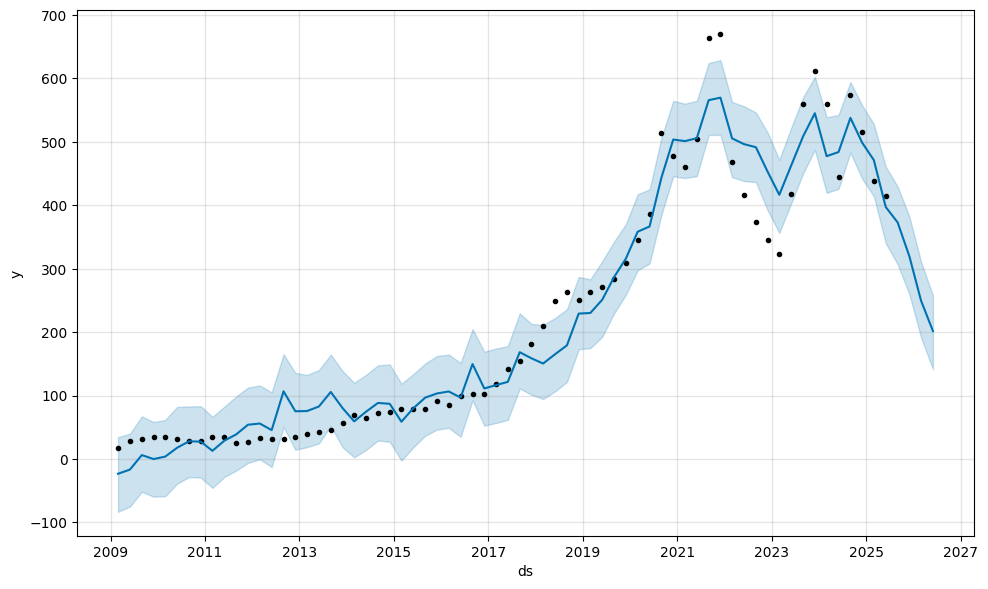

In [25]:
#12) PLOT THE RESULTS

figl = m.plot(forecast)
figl.show()

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_12582/3458915387.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


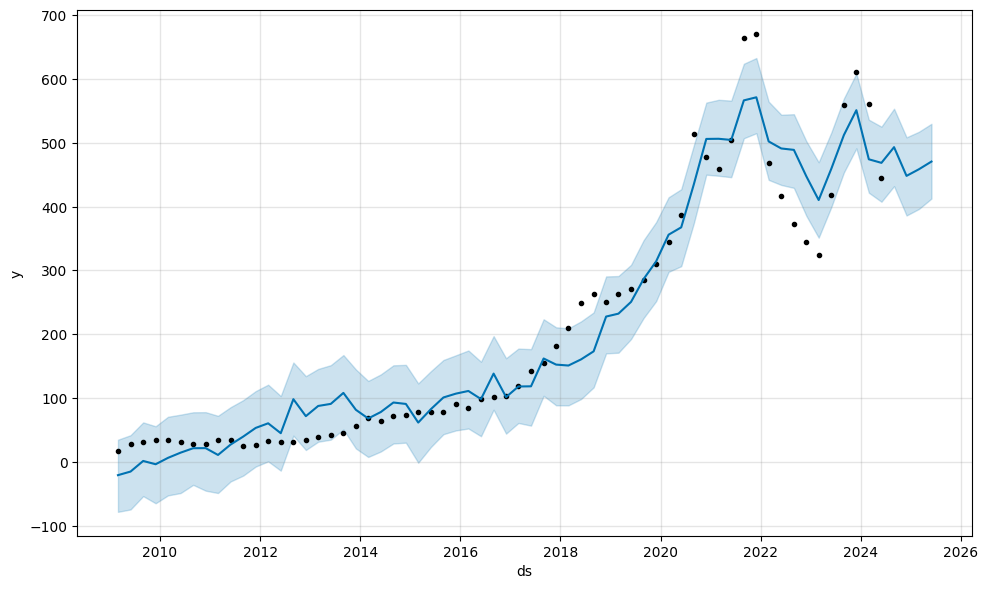

In [26]:
#12) PLOT THE RESULTS - BACKTESTING DATA

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()


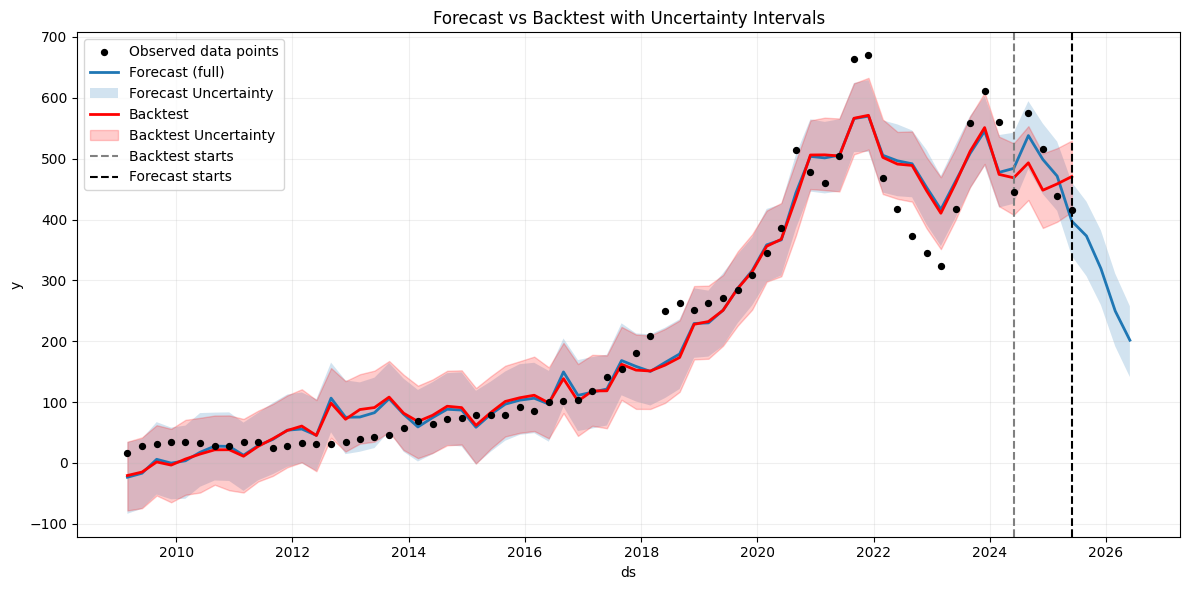

In [27]:
#13) PLOT THE FORECAST VS BACKTEST WITH UNCERTAINTY INTERVALS

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'].eq(False), 'ds'].max()   # ~2024-06-30
full_split = results.loc[results['is_future'].eq(False), 'ds'].max()         # ~2025-06-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()